/home/mtech/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mtech/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mtech/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


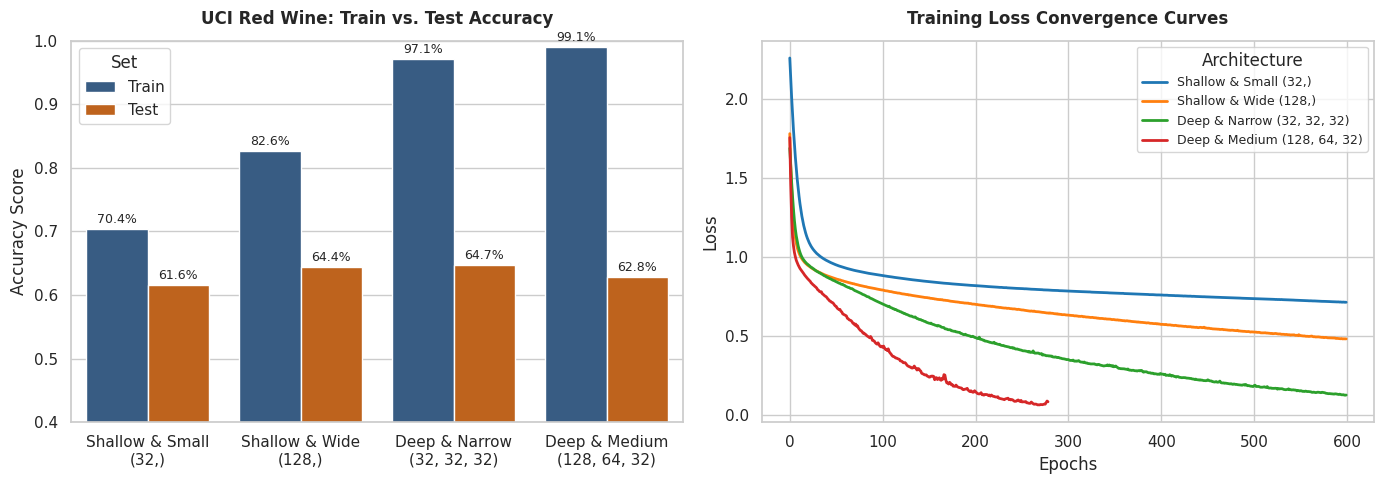

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Load the UCI Red Wine Quality dataset directly
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
# (If working offline, replace `url` with your local path, e.g., 'winequality-red.csv')
df = pd.read_csv(url, sep=';')

X = df.drop('quality', axis=1)
y = df['quality']

# Train/Test split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Crucial for MLP neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define network architectures to compare
architectures = {
    "Shallow & Small\n(32,)": (32,),
    "Shallow & Wide\n(128,)": (128,),
    "Deep & Narrow\n(32, 32, 32)": (32, 32, 32),
    "Deep & Medium\n(128, 64, 32)": (128, 64, 32)
}

# 3. Train models and store convergence loss + accuracy
results = []
for name, config in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=config, 
        activation='relu', 
        solver='adam', 
        max_iter=600, 
        random_state=42
    )
    mlp.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, mlp.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, mlp.predict(X_test_scaled))
    
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Loss Curve": mlp.loss_curve_
    })

# 4. Generate comparative plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Accuracy comparison bar chart
plot_data = []
for r in results:
    plot_data.append({"Model": r["Model"], "Accuracy": r["Train Accuracy"], "Set": "Train"})
    plot_data.append({"Model": r["Model"], "Accuracy": r["Test Accuracy"], "Set": "Test"})
plot_df = pd.DataFrame(plot_data)

sns.barplot(data=plot_df, x="Model", y="Accuracy", hue="Set", palette=["#2b5c8f", "#d95f02"], ax=axes[0])
axes[0].set_title("UCI Red Wine: Train vs. Test Accuracy", fontweight='bold', pad=12)
axes[0].set_ylim(0.4, 1.0)
axes[0].set_ylabel("Accuracy Score")
axes[0].set_xlabel("")

for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.1%}", 
                         (p.get_x() + p.get_width() / 2., h), 
                         ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

# Graph 2: Training loss convergence curves
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for idx, r in enumerate(results):
    axes[1].plot(r["Loss Curve"], label=r["Model"].replace('\n', ' '), color=colors[idx], linewidth=2)

axes[1].set_title("Training Loss Convergence Curves", fontweight='bold', pad=12)
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend(title="Architecture", fontsize=9)

plt.tight_layout()
plt.show()